## Import the necessary Libraries.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import re
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, Attention
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

## Load text file

In [2]:
def load_file(path):

    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)

    return text

## Read Dataset

In [3]:
train_text = load_file("/content/drive/MyDrive/wiki.train.tokens")
valid_text = load_file("/content/drive/MyDrive/wiki.valid.tokens")

print("Train length:", len(train_text))
print("Valid length:", len(valid_text))

Train length: 9700857
Valid length: 996875


## Combine Train + Valid

In [4]:
full_text = train_text + " " + valid_text

## Tokenization

In [5]:
vocab_size = 5000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<unk>"
)

tokenizer.fit_on_texts([full_text])

total_words = vocab_size

print("Vocabulary Size:", total_words)

Vocabulary Size: 5000


## Convert Text to Sequences

In [6]:
token_list = tokenizer.texts_to_sequences([full_text])[0]
print("Total tokens:", len(token_list))

Total tokens: 1868314


## Create N-gram Sequences

In [7]:
seq_length = 40

input_sequences = []

for i in range(seq_length, len(token_list)):

    seq = token_list[i-seq_length:i+1]

    input_sequences.append(seq)

input_sequences = np.array(input_sequences)

print("Total sequences:", len(input_sequences))

Total sequences: 1868274


## Convert to NumPy

In [8]:
input_sequences = np.array(input_sequences)
input_sequences

array([[3826, 3603,  848, ...,    1,  148,    6],
       [3603,  848,    1, ...,  148,    6,  213],
       [ 848,    1,   76, ...,    6,  213,    6],
       ...,
       [   6,   68,    5, ...,  117,   93, 1358],
       [  68,    5,    3, ...,   93, 1358,  357],
       [   5,    3,  352, ..., 1358,  357, 1358]])

## Padding

In [9]:
max_seq_len = input_sequences.shape[1]

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_seq_len,
    padding='pre'
)

## Create X and y

In [10]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1868274, 40)
y shape: (1868274,)


## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1494619, 40)
X_test: (373655, 40)


## Build LSTM Model

In [12]:
inputs = Input(shape=(seq_length,))

embedding = Embedding(vocab_size, 300)(inputs)

lstm1 = Bidirectional(LSTM(256, return_sequences=True))(embedding)
drop1 = Dropout(0.3)(lstm1)

lstm2 = Bidirectional(LSTM(256, return_sequences=True))(drop1)

attention = Attention()([lstm2, lstm2])

lstm3 = LSTM(128)(attention)

drop2 = Dropout(0.3)(lstm3)

dense1 = Dense(512, activation='relu')(drop2)

outputs = Dense(vocab_size, activation='softmax')(dense1)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 300)   │  1,500,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 512)   │  1,140,736 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 40, 512)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 40, 512)   │  1,574,912 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 40, 512)   │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │    328,192 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5000)      │  2,565,000 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,174,888 (27.37 MB)

 Trainable params: 7,174,888 (27.37 MB)

 Non-trainable params: 0 (0.00 B)

## Callbacks

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-5
)

## Train the Model

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 486s 102ms/step - accuracy: 0.1201 - loss: 6.0579 - val_accuracy: 0.1627 - val_loss: 5.6483 - learning_rate: 0.0010
Epoch 2/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 494s 106ms/step - accuracy: 0.1684 - loss: 5.4841 - val_accuracy: 0.1858 - val_loss: 5.2975 - learning_rate: 0.0010
Epoch 3/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 495s 106ms/step - accuracy: 0.1873 - loss: 5.2270 - val_accuracy: 0.1966 - val_loss: 5.1101 - learning_rate: 0.0010
Epoch 4/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 494s 106ms/step - accuracy: 0.1966 - loss: 5.0401 - val_accuracy: 0.2027 - val_loss: 4.9945 - learning_rate: 0.0010
Epoch 5/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 495s 106ms/step - accuracy: 0.2020 - loss: 4.9053 - val_accuracy: 0.2086 - val_loss: 4.8973 - learning_rate: 0.0010
Epoch 6/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 496s 106ms/step - accuracy: 0.2081 - loss: 4.7813 - val_accuracy: 0.2117 - val_loss: 4.8287 - learning_rate: 0.0010
Epoch 7/30
4671/4671 ━━━━━━━━━━━━━━━━━━━━ 497s 106ms

## Evaluate on Test Set

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

11677/11677 ━━━━━━━━━━━━━━━━━━━━ 116s 10ms/step - accuracy: 0.2278 - loss: 4.6910
Test Loss: 4.6863837242126465
Test Accuracy: 0.22779034078121185


## Plot Accuracy & Loss

In [16]:
plt.style.use("seaborn-v0_8")

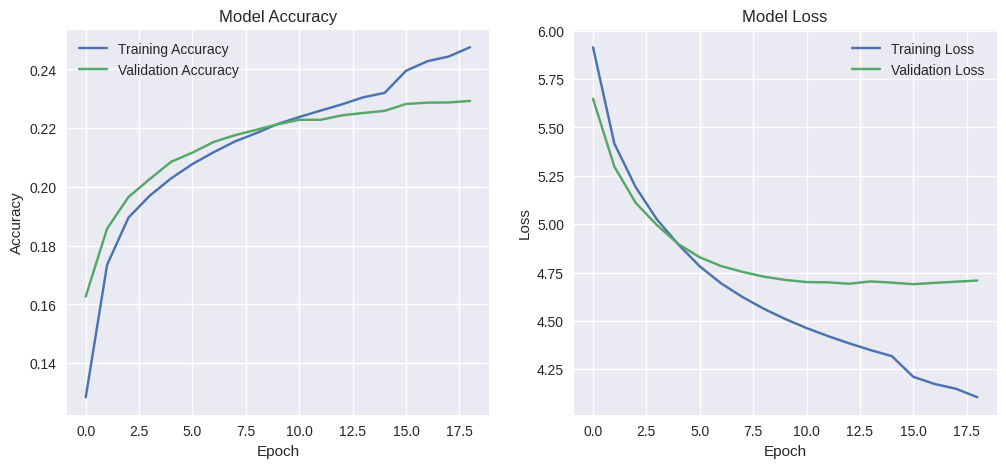

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Text Generation Function

In [18]:
def predict_next_word(model, tokenizer, text, max_sequence_len):

    token_list = tokenizer.texts_to_sequences([text])[0]

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding='pre'
    )

    predicted = model.predict(token_list, verbose=0)

    predicted_index = np.argmax(predicted)

    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word

    return ""

## Test Model

In [20]:
seed_text = "machine learning is used"

next_word = predict_next_word(model, tokenizer, seed_text, max_seq_len)

print("Input:", seed_text)
print("Predicted word:", next_word)

Input: machine learning is used
Predicted word: to


## perplexity = np.exp(test_loss)

print("Model Perplexity:", perplexity)

In [21]:
perplexity = np.exp(test_loss)
print("Perplexity:", perplexity)

Perplexity: 108.46024759274152
